Estimated alpha: 0.1000
Estimated c_b: 1.000000
Estimated t0: 50.000000


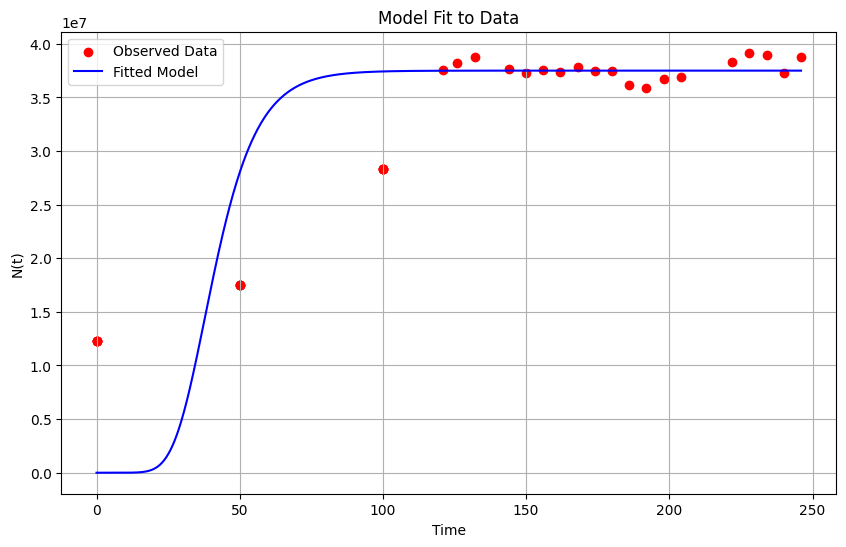

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Given constants
N_0 = 28000000
N_bar = 37500000

# Provided data
time = np.array([0, 50, 100,0, 50, 100,0, 50, 100,0, 50, 100, 121, 126, 132, 144, 150, 156, 162, 168, 174, 180, 186,
                 192, 198, 204, 222, 228, 234, 240, 246])
N_t = np.array([12273000, 17497900, 28287200,12273000, 17497900, 28287200,12273000, 17497900, 28287200,12273000, 17497900, 28287200, 37534207, 38230557, 38767415, 37660968,
                37321675, 37529035, 37326899, 37802962, 37426249, 37455264, 36124511,
                35843675, 36678287, 36895618, 38307038, 39170016, 38972026, 37322513,
                38746980])

# Model function based on the provided formula
def model(t, alpha, c_b, t0):
    numerator = N_bar**alpha
    denominator = 1 - (1 - (N_bar/N_0)**alpha) * np.exp(-alpha * c_b * (t-t0))
    return (numerator / denominator)**(1/alpha)


# Curve fitting with bounds to ensure meaningful values
result = curve_fit(model, time, N_t, bounds=([0.1, 1, -50], [0.9, 5.5, 50]))

popt, pcov = result

# Extract estimated parameters
alpha_est, c_b_est, t0_est = popt

print(f"Estimated alpha: {alpha_est:.4f}")
print(f"Estimated c_b: {c_b_est:.6f}")
print(f"Estimated t0: {t0_est:.6f}")

# Predicted values for plotting
pred_time = np.linspace(time[0], time[-1], 1000)
N_pred = model(pred_time, alpha_est, c_b_est, t0_est)

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(time, N_t, label='Observed Data', color='red')
plt.plot(pred_time, N_pred, label='Fitted Model', color='blue')
plt.xlabel('Time')
plt.ylabel('N(t)')
plt.title('Model Fit to Data')
plt.legend()
plt.grid(True)
plt.show()


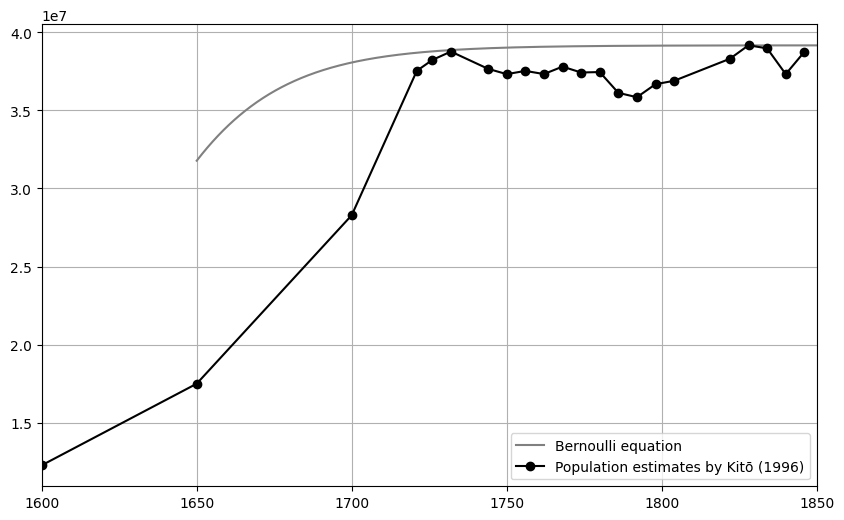

In [3]:
from matplotlib.ticker import ScalarFormatter


time = np.array([0, 50, 100, 121, 126, 132, 144, 150, 156, 162, 168, 174, 180, 186,
                 192, 198, 204, 222, 228, 234, 240, 246])
N_t = np.array([12273000, 17497900, 28287200, 37534207, 38230557, 38767415, 37660968,
                37321675, 37529035, 37326899, 37802962, 37426249, 37455264, 36124511,
                35843675, 36678287, 36895618, 38307038, 39170016, 38972026, 37322513,
                38746980])

def model(t, alpha, c_b):
    numerator = N_bar**alpha
    denominator = 1 - (1 - (N_bar/N_0)**alpha) * np.exp(-alpha * c_b * (t))
    return (numerator / denominator)**(1/alpha)

pred_time = np.linspace(time[0], time[-1], 1000)

N_pred = model(pred_time*2, 0.055, 0.37)*3.5/4.5 +10**7
plt.figure(figsize=(10, 6))
plt.plot(pred_time + 1650, N_pred, label='Bernoulli equation', color='gray')
plt.plot(time + 1600, N_t, label='Population estimates by Kitō (1996)', color='black', marker='o')
plt.xlim(1600, 1850)
ax = plt.gca()
ax.xaxis.set_major_formatter(ScalarFormatter(useMathText=False))
ax.ticklabel_format(style='plain', axis='x')

plt.legend()
plt.grid(True)
plt.show()


(array([ 0.1,  1. , 50. ]), array([[ 7.54252247e+07, -7.52066470e+08, -1.98474805e+02],
       [-7.52066470e+08,  7.49887037e+09,  1.97937765e+03],
       [-1.98474805e+02,  1.97937765e+03,  1.91374996e+01]]))


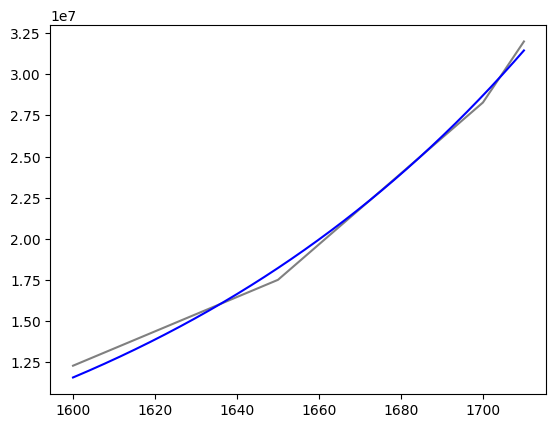

In [4]:

def model_1(t, a, b):
    return a*np.exp(b*t)

time = [1600,1650,1700,1710]
values = [12273000, 17497900, 28287200, 32000000]
#result = curve_fit(model, time, values, bounds=([0.01, 0.0001], [100, 10]))
print(result)
a = 5.47146195
b = 9.10203483 *10**(-3)

pred_time = np.linspace(time[0], time[-1], 1000)
plt.plot(time, values, label='Bernoulli equation', color='gray')
plt.plot(pred_time, model_1(pred_time, a,b), label='Fitted Model', color='blue')
plt.show()

2938.673893008633 0.046295375124887204


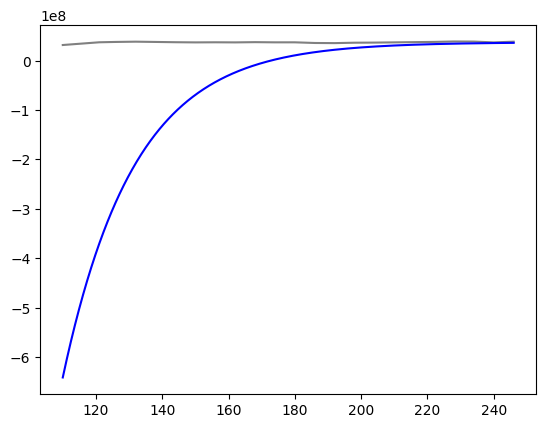

In [5]:
time = np.array([110, 121, 126, 132, 144, 150, 156, 162, 168, 174, 180, 186,
                 192, 198, 204, 222, 228, 234, 240, 246])
values = np.array([32000000, 37534207, 38230557, 38767415, 37660968,
                37321675, 37529035, 37326899, 37802962, 37426249, 37455264, 36124511,
                35843675, 36678287, 36895618, 38307038, 39170016, 38972026, 37322513,
                38746980])
n_bar = 37637678

def model_2(t, c, d, t_0):
    return n_bar*(1-c*np.exp(-d*(t-t_0)))

t_s = 110
t0= 0
d = model_1(t_s+1600,a*b,b)/(n_bar-model_1(t_s+1600,a,b))
c = model_1(t_s+1600,a,b)*model_1(t_s-t0,1/d,d)/n_bar
print(c,d)
#result = curve_fit(model, time, values, bounds=([0.01, 0.0001, -50], [2, 1, 50]))
#print(result)
pred_time = np.linspace(time[0], time[-1], 1000)
plt.plot(time, values, label='Bernoulli equation', color='gray')
plt.plot(pred_time, model_2(pred_time, c,d,t0), label='Fitted Model', color='blue')
plt.show()

1000
22


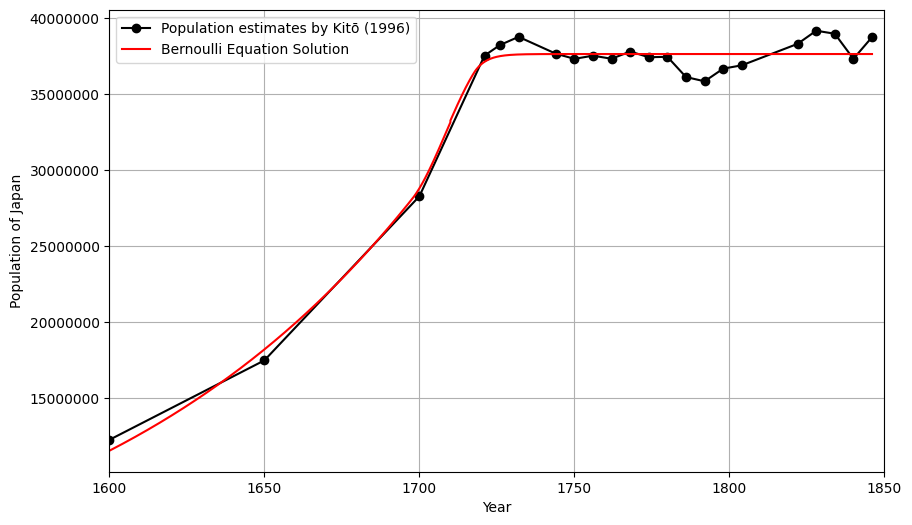

In [16]:
from scipy.interpolate import CubicSpline

time_1 = np.array([1600,1650,1700,1710])
time_2 = np.array([110, 121, 126, 132, 144, 150, 156, 162, 168, 174, 180, 186,
                 192, 198, 204, 222, 228, 234, 240, 246])
time = np.array([0, 50, 100, 121, 126, 132, 144, 150, 156, 162, 168, 174, 180, 186,
                 192, 198, 204, 222, 228, 234, 240, 246])
values = np.array([12273000, 17497900, 28287200, 37534207, 38230557, 38767415, 37660968,
                37321675, 37529035, 37326899, 37802962, 37426249, 37455264, 36124511,
                35843675, 36678287, 36895618, 38307038, 39170016, 38972026, 37322513,
                38746980])

a1 = 5.47146195
b1 = 9.10203483 *10**(-3)
a2 = 43.36
b2 = 0.2603275
t0= 90

time_1 = np.linspace(time_1[0], time_1[-1], 450)
time_2 = np.linspace(time_2[0], time_2[-1], 550)


val1= model_1(time_1, a1, b1)
val2= model_2(time_2, a2, b2,t0)


val = np.concatenate((val1,val2))
print(len(val))
print(len(time))

val[400:480] = np.nan  # Assume missing values are NaN


# Identify known x and y points
x_known = np.concatenate((np.arange(0, 400), np.arange(480, 1000)))
y_known = np.concatenate((val[:400], val[480:]))

# Build cubic spline interpolator
cs = CubicSpline(x_known, y_known)

# Fill the gap with smooth interpolation
val[400:480] = cs(np.arange(400, 480))
time_val = np.concatenate((time_1,time_2+1600))

plt.figure(figsize=(10, 6))
plt.plot(time + 1600, values, label='Population estimates by Kitō (1996)', color='black', marker='o')
plt.plot(time_val, val, label='Bernoulli Equation Solution', color='red')
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
plt.xlim(1600, 1850)
plt.xlabel('Year')
plt.ylabel('Population of Japan')
plt.legend()
plt.grid(True)
plt.show()


In [49]:
def model(t, alpha, c_b, t0,N0):
    numerator = N_bar**alpha
    denominator = 1 - (1 - (N_bar/N0)**alpha) * np.exp(-alpha * c_b * (t-t0))
    return (numerator / denominator)**(1/alpha)

result = curve_fit(model, time_val, val, bounds=([0.01, 0.0001, -2000, 1], [1, 10, 2000, 3*10**7]))

alpha_grid = np.linspace(0.99,0.99999,15)
c_grid = np.linspace(0.01,0.04,75)
t_0_grid = np.linspace(1550, 1750, 25)
N_0_grid = np.linspace(1,10**7,25)


error = np.inf
for alpha in alpha_grid:
    for c in c_grid:
        for t in t_0_grid:
            for N_0 in N_0_grid:
                model_values = model(time_val, alpha, c, t, N_0)
                new_error = np.sum((model_values - val) ** 2)
                if error > new_error:
                    error = new_error
                    val_results=[alpha, c, t, N_0]

print(error)
print(val_results)

KeyboardInterrupt: 

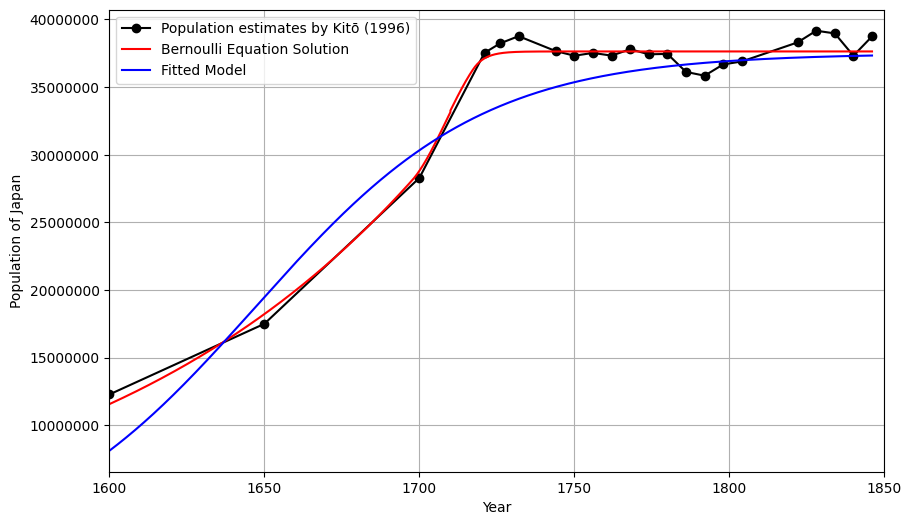

In [48]:
pred_val = model(time_val, *val_results)

plt.figure(figsize=(10, 6))
plt.plot(time + 1600, values, label='Population estimates by Kitō (1996)', color='black', marker='o')
plt.plot(time_val, val, label='Bernoulli Equation Solution', color='red')
plt.plot(time_val, pred_val , label='Fitted Model', color='blue')
plt.gcf().axes[0].yaxis.get_major_formatter().set_scientific(False)
plt.xlim(1600, 1850)
plt.xlabel('Year')
plt.ylabel('Population of Japan')
plt.legend()
plt.grid(True)
plt.show()

In [127]:
pred_val = model((time_val-70), *val_results)

pred_val =  np.delete(pred_val, 450)

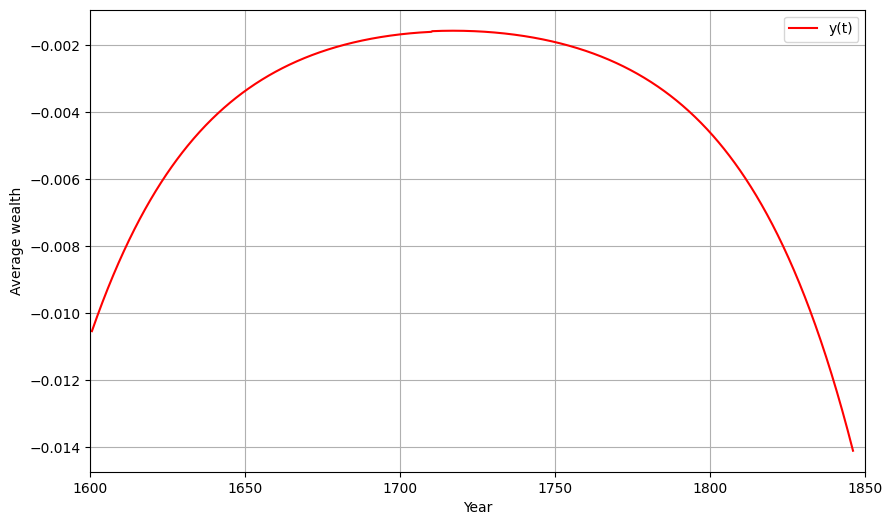

In [129]:
n = pred_val[1:] - pred_val[:-1]
y = 100/(1-n)
plt.figure(figsize=(10, 6))
plt.plot(time_val[2:], y, label='y(t)', color='red')
#plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
plt.xlim(1600, 1850)
plt.xlabel('Year')
plt.ylabel('Average wealth')
plt.legend()
plt.grid(True)
plt.show()


In [24]:
def model(t, alpha, P, Q, t_0, N_0):
    N=(Q+(N_0**alpha-Q)*np.exp(-alpha*P*(t-t_0)))**(1/alpha)
    return N

alpha_grid = np.linspace(0.001,0.999,15)
p_grid = np.linspace(0.001,0.99,15)
q_grid = np.linspace(0.01,2.99,15)
t_0_grid = np.linspace(1550, 1750, 15)
N_0_grid = np.linspace(1,10**7,15)


error = np.inf
for alpha in alpha_grid:
    for p in p_grid:
        for q in q_grid:
            for t_0 in t_0_grid:
                for N_0 in N_0_grid:
                    model_values = model(time_val, alpha, p,q, t_0, N_0)
                    new_error = np.sum((model_values - val) ** 2)
                    if error > new_error:
                        error = new_error
                        val_results=[alpha, p, q, t_0, N_0]

print(error)
print(val_results)


C:\Users\leocr\AppData\Local\Temp\ipykernel_10432\3461091214.py:19: RuntimeWarning: overflow encountered in square
  new_error = np.sum((model_values - val) ** 2)
C:\Users\leocr\Projects\Economics\.venv\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\leocr\AppData\Local\Temp\ipykernel_10432\3461091214.py:2: RuntimeWarning: invalid value encountered in power
  N=(Q+(N_0**alpha-Q)*np.exp(-alpha*P*(t-t_0)))**(1/alpha)


8.931218116830053e+16
[np.float64(0.001), np.float64(0.1422857142857143), np.float64(1.0742857142857145), np.float64(1592.857142857143), np.float64(7857143.071428571)]
